<!-- mtlearn-icpr2026-doc -->
# Plant Segmentation with U-Net MobileNetV2

This notebook compares the U-Net MobileNetV2 backbone with and without Connected Filter Preprocessing (CFP) for plant segmentation. The baseline model operates directly on the input image, whereas the CFP variant applies a trainable morphological preprocessing layer based on attributes derived from component trees in MTLearn.

The results shown below correspond to one of ten random runs for this configuration, as reported in the paper. We present the observed training curves, qualitative predictions, and final evaluation metrics.


<!-- mtlearn-icpr2026-doc -->
## Run Parameters

The first cells define the run identifier, random seed, and output directory used by the executed experiment. They are kept as code cells so the notebook remains compatible with Papermill-style batch execution.


In [1]:
# Parameters
RUN_ID = 0
SEED = 2684470948
OUT_DIR = "/Users/wonderalexandre/GitHub/mtlearn/notebooks/icpr2016/out_plants_unet/runs"


<!-- mtlearn-icpr2026-doc -->
## Environment and Helpers

This setup imports PyTorch, MTLearn morphology utilities, image-processing helpers, plotting utilities, and small notebook functions used to visualize samples and control randomness. The selected device can be CUDA, Apple MPS, or CPU, depending on the local runtime.


In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp
import torch
import numpy as np
from mtlearn import morphology
import mtlearn
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
import time
import os, random

def fix_randomness(seed: int = 42, deterministic: bool = True):
    """Set Python, NumPy, and PyTorch random seeds for reproducible notebook runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        # cuDNN and deterministic algorithm selection
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True, warn_only=True)

        # Some GPU GEMM operations need this for bitwise determinism
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # or ":16:8"

fix_randomness(SEED)     
generator = torch.Generator(device="cpu")
generator.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


# Dataset

<!-- mtlearn-icpr2026-doc -->
The plant dataset is loaded from the local MTLearn dataset registry. Because the plant image collection is not bundled with the public repository, it must be requested from the plant phenotyping dataset portal at https://www.plant-phenotyping.org/datasets-home and configured locally before this notebook can be rerun. The dataset section resizes the input images, builds the train/test split, and prepares tensors for binary segmentation. The next cell also estimates foreground/background imbalance so the loss can compensate for sparse positive pixels.


In [6]:
num_cols, num_rows =(int(1177 * 0.5), int(1324 * 0.499)) 
print("Resolution: ", num_cols, "x", num_rows)

dir_name = str(mtlearn.data.require_local_dataset(
    "PlantasDataset",
    env_var="MTLEARN_PLANTS_DATASET",
    description="ICPR plants segmentation dataset",
))
dataset = mtlearn.datasets.PairedImageDataset(root_dir=dir_name, grayscale_in=True,  numRows=num_rows, numCols=num_cols, scale_in=False, suffix_in="_tfb", suffix_target="_fg")
trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("Train set:", len(trainset))
print("Test set:", len(testset))

# Move train/test sets to the selected device
trainset = [(entradas.to(device), saidas.to(device), nameFiles) for entradas, saidas, nameFiles in trainset]
testset= [(entradas.to(device), saidas.to(device), nameFiles) for entradas, saidas, nameFiles in testset]
trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, pin_memory=False, generator=generator)


Resolution:  588 x 660
Train set: 48
Test set: 21


In [7]:
# Compute the class-imbalance ratio
num_neg = []
num_pos = []
for i in range(len(trainset)):
    x, y, _ = trainset[i]
    num_neg.append((y == 0).sum().item())
    num_pos.append((y == 1).sum().item())

# Compute class proportions
total_neg = sum(num_neg)
total_pos = sum(num_pos)
total_samples = total_neg + total_pos

percent_neg = (total_neg / total_samples) * 100
percent_pos = (total_pos / total_samples) * 100

print(f"Total class 0 samples: {total_neg} ({percent_neg:.2f}%)")
print(f"Total class 1 samples: {total_pos} ({percent_pos:.2f}%)")

pos_weight = torch.tensor([total_neg / total_pos])  # 8498057 / 530683 ≈ 16
print(f"pos_weight: {pos_weight}")

Total class 0 samples: 17528157 (94.10%)
Total class 1 samples: 1099683 (5.90%)
pos_weight: tensor([15.9393])


# Models

<!-- mtlearn-icpr2026-doc -->
The model section defines two comparable variants. `BaseNet` is the U-Net MobileNetV2 backbone used as the neural baseline. `BackboneWithConnectedFilterLayer` wraps the same backbone with a CFP layer so the network receives a learnable connected-filtered representation before segmentation.


In [8]:
class BaseNet(nn.Module):
    """U-Net MobileNetV2 segmentation backbone used as the baseline network."""
    def __init__(self, num_rows, num_cols, device='cpu'):
        """Create the backbone layers and move the module to the selected device."""
        super(BaseNet, self).__init__()
        self.device = device
        self.num_rows = num_rows
        self.num_cols = num_cols

        # Fully connected layer and LayerNorm running on the GPU
        self.net = smp.Unet(
            encoder_name="mobilenet_v2", 
            encoder_weights=None, 
            in_channels=1, 
            encoder_depth=3,
            decoder_channels=(32, 16, 8),
            classes=1
        ).to(device)

    def forward(self, inputs):
        """Run the backbone forward pass and return segmentation logits."""
        if type(inputs) == list:
            out = self.net(inputs[0])
        else:
            out = self.net(inputs)
        return out


class BackboneWithConnectedFilterLayer(nn.Module):
    """Compose the CFP layer with the backbone for CFP-enhanced segmentation."""
    def __init__(self, layer_connected_filter, num_rows, num_cols, num_hidden, device='cpu'):
        """Store the CFP layer, create the downstream backbone, and keep both on the selected device."""
        super(BackboneWithConnectedFilterLayer, self).__init__()
        self.device = device
        num_pixels = num_rows * num_cols
        self.morphological_layer = layer_connected_filter
        self.net = BaseNet(num_rows, num_cols, device)
        

    def forward(self, inputs):
        """Apply CFP to the input image and feed the filtered tensor into the backbone."""
        self.h_filter = self.morphological_layer(inputs)
        return self.net(self.h_filter)


<!-- mtlearn-icpr2026-doc -->
## CFP Layer Configuration

The CFP layer is configured with a max-tree and a set of morphological attributes. During training, the layer learns how to combine connected filters before passing the transformed image to the backbone, allowing the comparison to isolate the effect of morphological preprocessing.


In [9]:
Type = morphology.AttributeType
tree_type = "max-tree"
layer_connected_filter = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=1,
    attributes_spec=[(Type.AREA,
                      Type.INERTIA,
                      Type.GRAY_HEIGHT,
                      Type.VARIANCE_LEVEL,
                      Type.BITQUADS_PERIMETER_CONTINUOUS,
                      )],   
    tree_type=tree_type,
    top_hat=False,
    clamp_logits=False,
    device=device
)

# Create a cached train loader used during training
layer_connected_filter.build_dataloader_cached(trainloader) 
layer_connected_filter.init_identity_with_bias()  


[ConnectedFilterPreprocessingLayer] Preprocessing dataset using mode 'hybrid'...


  [6/6] batches processed.
[ConnectedFilterPreprocessingLayer] Full and normalized cache with 'hybrid'.


# Training

<!-- mtlearn-icpr2026-doc -->
The training utilities separate regular neural-network parameters from CFP parameters, because the morphological layer can use its own learning rate. This keeps the baseline and CFP-enhanced runs comparable while still giving the preprocessing layer enough optimization flexibility.


In [10]:

def split_params(model):
    """Split model parameters into CFP and non-CFP groups for separate optimizer settings."""
    filtro_mod = model.morphological_layer  # CFP module whose parameters use a separate optimizer group
    filtro_ids = set(map(id, filtro_mod.parameters()))
    params_filtro = [p for p in model.parameters() if id(p) in filtro_ids]
    params_resto  = [p for p in model.parameters() if id(p) not in filtro_ids]
    return params_filtro, params_resto

# --- 2) Mini-scheduler para λ da aux-loss ---
class LambdaAuxScheduler:
    """Schedule the auxiliary CFP regularization weight during training."""
    def __init__(self, total_epochs, max_val=0.3, warmup=20, hold=40, decay_to=0.0):
        """Configure warmup, plateau, and decay phases for the CFP auxiliary loss weight."""
        self.E = total_epochs
        self.max_val, self.warmup, self.hold, self.decay_to = max_val, warmup, hold, decay_to
        self.last_epoch = -1
        self.value = 0.0

    def step(self, epoch=None):
        """Update the current lambda value for the given training epoch."""
        if epoch is None:
            self.last_epoch += 1
        else:
            self.last_epoch = epoch
        e = self.last_epoch
        # warmup -> plateau -> linear decay to decay_to
        if e < self.warmup:
            self.value = self.max_val * (e / max(1, self.warmup))
        elif e < self.hold:
            self.value = self.max_val
        elif e >= self.E:
            self.value = 0
        else:
            t = min((e - self.hold) / max(1, self.E - self.hold), 1.0)
            self.value = self.max_val * (1 - t) + self.decay_to * t


def training(model, lr=0.01, lr_cfp=0.05, lambda_filter=1, num_epochs_filter=0, num_epochs=100):

    
    """Train a model for one run and display loss curves and qualitative predictions."""
    loss_aux = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device), reduction="sum")
    loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    lambda_sched = LambdaAuxScheduler(num_epochs_filter, max_val=lambda_filter, warmup=0, hold=10, decay_to=0.0)

    if(num_epochs_filter != 0):
        params_cfp, params_backbone = split_params(model)
        optimizer = torch.optim.Adam(
            [
                {"params": params_backbone,  "lr": lr,   "weight_decay": 1e-7},
                {"params": params_cfp, "lr": lr_cfp, "weight_decay": 1e-7},
            ]
        )
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-7)
        
    errors = []
    model.train()
    time_begin = time.time()
    for epoch in range(num_epochs):  
        epoch_loss = 0
        lambda_sched.step(epoch)                 # update lambda for this epoch
        lam = lambda_sched.value               
        for i, (inputs, targets) in enumerate(trainloader_cached):
            
            
            # Forward
            predicts = model(inputs)
            
            # Loss
            if epoch < num_epochs_filter:
                c_filter = model.h_filter
                loss_main = loss_function(predicts, targets)
                loss_filter = loss_aux(c_filter, targets)
                loss = loss_main + lam * loss_filter
            else:
                loss = loss_function(predicts, targets)
            
            epoch_loss += loss.item()
    
            # Backward + Optimize
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
        errors.append(epoch_loss / len(trainloader))
        if(epoch % 10 == 0 or epoch == num_epochs-1):
            print(f"Epoch {epoch}, Loss: {errors[-1]:.7f}, Learning rate: {lr:.6f}")
            if epoch < num_epochs_filter:
                print(f"\tLoss (main): {loss_main.item():.7f}, Loss (filter): {loss_filter.item():.7f}, Lambda: {lam:.4f}")
        
        if(num_epochs_filter != 0 and (epoch == num_epochs-1 or epoch % 20 == 0)):    
            (imgs_in, keys_in), imgs_out = inputs, targets.to("cpu")
            h_filter = model.h_filter.cpu()
            imgs_pred = (torch.sigmoid(predicts).cpu().detach().numpy() >= 0.5).astype(int)
            
            i = np.random.randint(0, len(imgs_out))
            fig, ax = plt.subplots(1, 4, figsize=(12, 3))
            ax[0].imshow(imgs_in[i,0].cpu().numpy(), cmap="gray");  ax[0].set_title("Input")
            ax[1].imshow(imgs_out[i,0].numpy(), cmap="gray"); ax[1].set_title("Target")
            ax[2].imshow(h_filter[i,0].detach().numpy(), cmap="gray");    ax[2].set_title("CFilter")
            ax[3].imshow(imgs_pred[i,0], cmap="gray");    ax[3].set_title("Pred")
            for a in ax: a.axis("off")
            plt.tight_layout(); plt.show()
    
        
    
    time_end = time.time()
    print('Finish training')
    print(f"Execution time: {(time_end - time_begin)/60:.3f} minutes")
    
    plt.figure(figsize=(12, 5))
    plt.plot(errors, '-')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (mean)')
    plt.title('Loss Evolution')
    plt.show()


<!-- mtlearn-icpr2026-doc -->
## Baseline Training

This run trains the U-Net MobileNetV2 backbone without CFP. It provides the reference performance for the dataset, architecture, seed, and training schedule used in this notebook.


Epoch 0, Loss: 1.1015554, Learning rate: 0.001000


Epoch 10, Loss: 0.5989658, Learning rate: 0.001000


Epoch 20, Loss: 0.2736082, Learning rate: 0.001000


Epoch 30, Loss: 0.1461838, Learning rate: 0.001000


Epoch 40, Loss: 0.1215045, Learning rate: 0.001000


...

Epoch 60, Loss: 0.0506119, Learning rate: 0.001000


Epoch 70, Loss: 0.0439918, Learning rate: 0.001000


Epoch 80, Loss: 0.0395296, Learning rate: 0.001000


Epoch 90, Loss: 0.0362684, Learning rate: 0.001000


Epoch 99, Loss: 0.0365039, Learning rate: 0.001000
Finish training
Execution time: 6.249 minutes


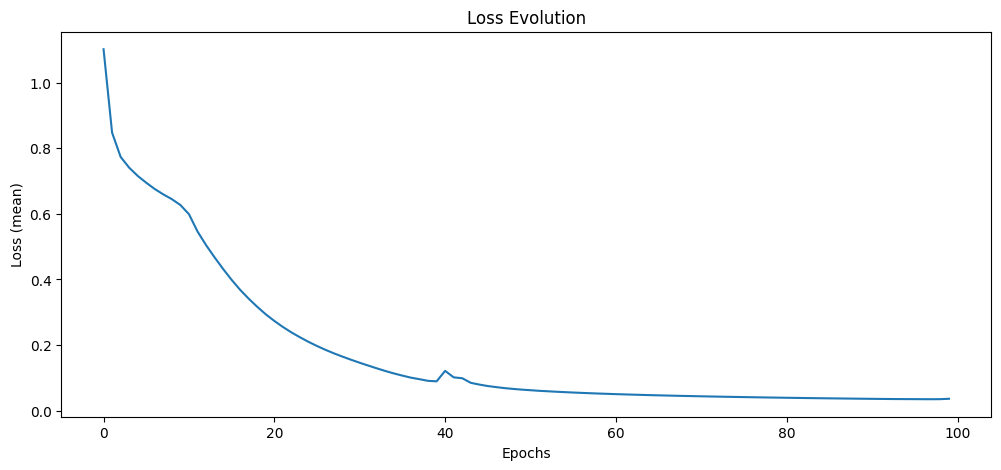

In [11]:
model_base = BaseNet(num_rows, num_cols, device)
training(model_base, lr=0.001, num_epochs=100)

<!-- mtlearn-icpr2026-doc -->
## Backbone with CFP Training

This run trains the same backbone with CFP placed before it. The goal is to measure whether the learnable connected operator improves segmentation when all other experimental conditions remain aligned with the baseline.


Epoch 0, Loss: 104283432.0000000, Learning rate: 0.001000
	Loss (main): 0.9810836, Loss (filter): 106593848.0000000, Lambda: 1.0000


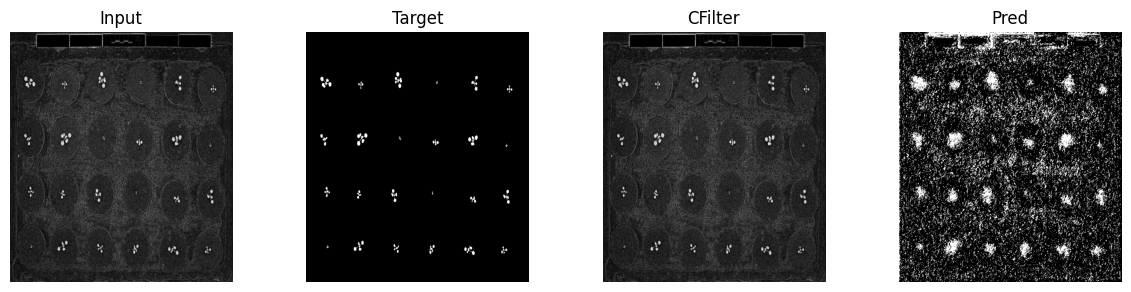

Epoch 10, Loss: 2904768.3333333, Learning rate: 0.001000
	Loss (main): 0.3502463, Loss (filter): 2926334.2500000, Lambda: 1.0000


Epoch 20, Loss: 2023128.0208333, Learning rate: 0.001000
	Loss (main): 0.1169482, Loss (filter): 2729821.5000000, Lambda: 0.7500


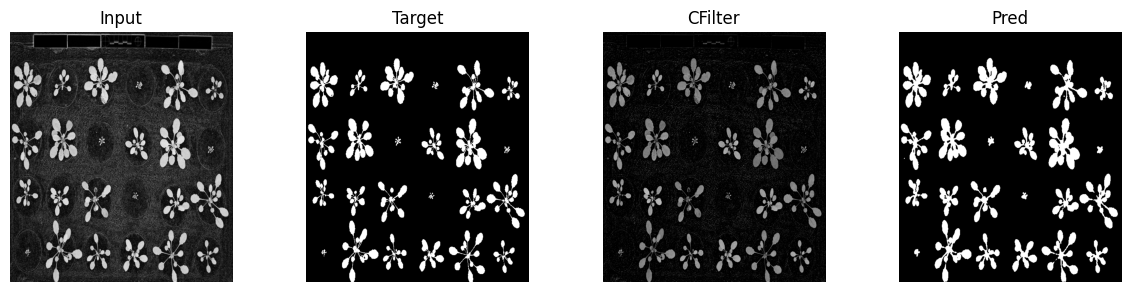

Epoch 30, Loss: 1282253.3333333, Learning rate: 0.001000
	Loss (main): 0.0797118, Loss (filter): 2628407.5000000, Lambda: 0.5000


Epoch 40, Loss: 624703.3229167, Learning rate: 0.001000
	Loss (main): 0.0641735, Loss (filter): 2586976.7500000, Lambda: 0.2500


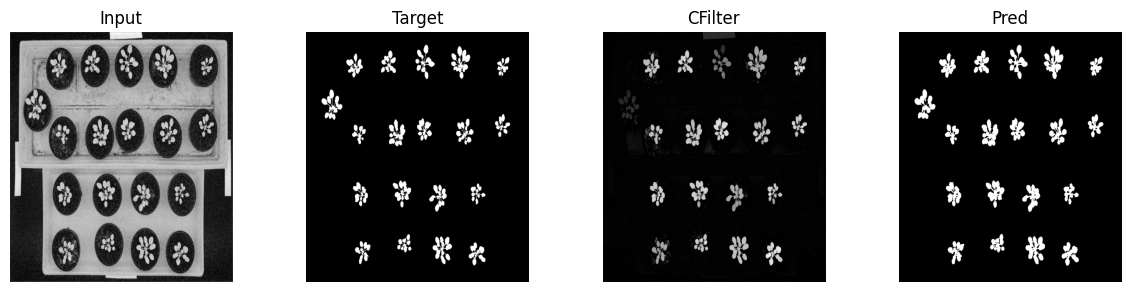

Epoch 50, Loss: 0.1159856, Learning rate: 0.001000


Epoch 60, Loss: 0.0440775, Learning rate: 0.001000


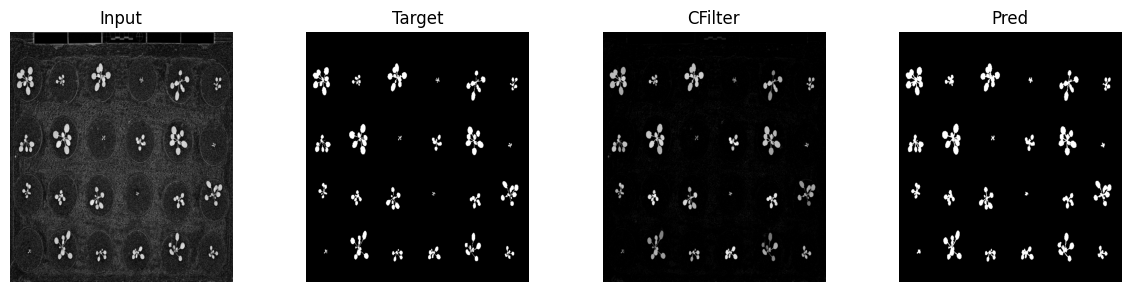

Epoch 70, Loss: 0.0379277, Learning rate: 0.001000


Epoch 80, Loss: 0.0346116, Learning rate: 0.001000


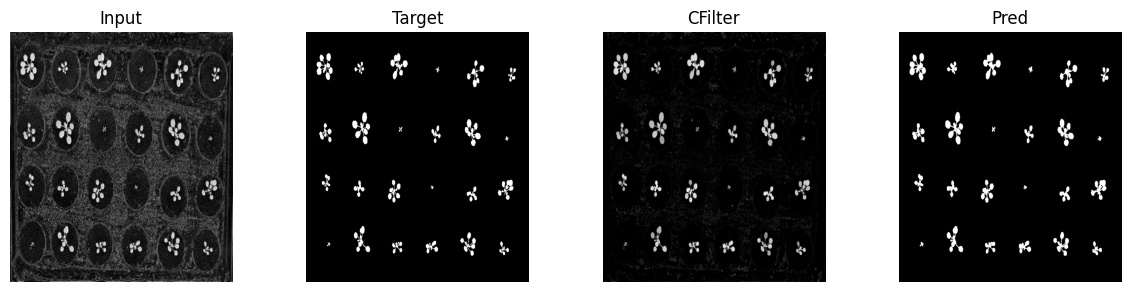

Epoch 90, Loss: 0.0321474, Learning rate: 0.001000


Epoch 99, Loss: 0.0331263, Learning rate: 0.001000


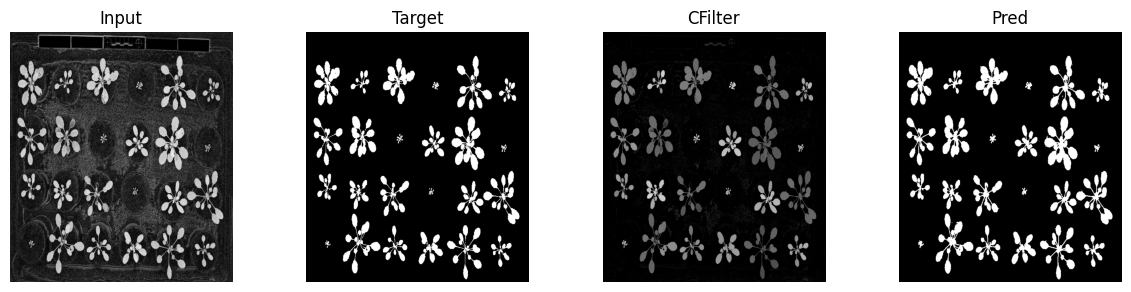

Finish training
Execution time: 10.799 minutes


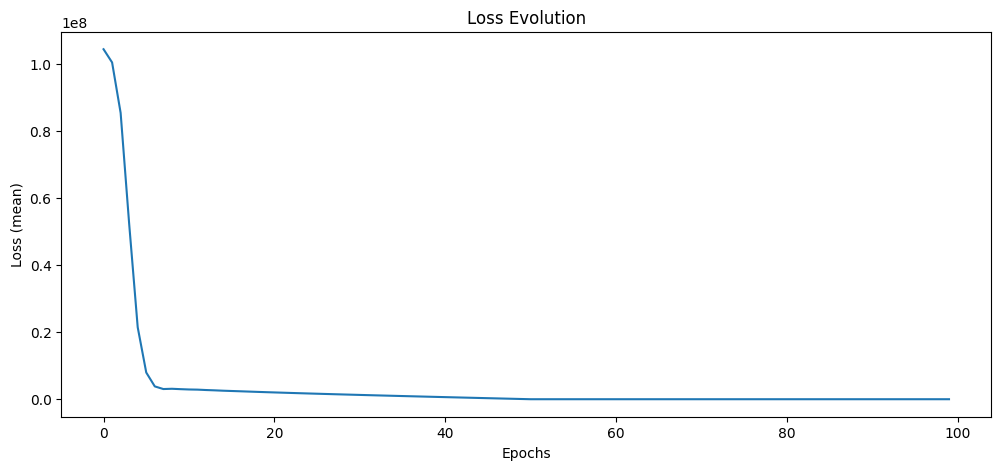

In [12]:
model = BackboneWithConnectedFilterLayer(layer_connected_filter, num_rows, num_cols, num_hidden=num_rows * num_cols, device=device)
training(model, lr=0.001, lr_cfp=0.05, num_epochs_filter=50, num_epochs=100)

<!-- mtlearn-icpr2026-doc -->
## Threshold Selection

The model outputs probability maps. This section evaluates ROC and precision-recall curves on the test set to choose operating thresholds before computing binary segmentation metrics.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

def analyze_threshold(model, dataloader, save_path=None):
    """Compute ROC and precision-recall curves and return the selected thresholds."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for entradas, saida_desejadas, names in dataloader:
            logits = model(entradas)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(saida_desejadas.cpu().numpy().flatten())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Compute the ROC curve and AUC
    fpr, tpr, thresholds_roc = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    best_idx_roc = np.argmax(tpr - fpr)
    best_threshold_roc = thresholds_roc[best_idx_roc]

    # Compute the precision-recall curve
    precision, recall, thresholds_pr = precision_recall_curve(all_labels, all_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx_pr = np.argmax(f1_scores[1:])
    best_threshold_pr = thresholds_pr[best_idx_pr-1]

    # Plot the ROC curve
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.scatter(fpr[best_idx_roc], tpr[best_idx_roc], c='red', label=f"Best Threshold = {best_threshold_roc:.2f}")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend()

    # Plot the precision-recall curve
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label="Precision-Recall Curve")
    plt.scatter(recall[best_idx_pr], precision[best_idx_pr], c='red', label=f"Best Threshold = {best_threshold_pr:.2f}")
    plt.title("Precision vs Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    # Save the plots
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()

    return best_threshold_roc, best_threshold_pr


<!-- mtlearn-icpr2026-doc -->
## Segmentation Metrics

The metric helper reports pixel-level and region-overlap measures such as accuracy, precision, recall, F1 score, IoU/Jaccard, Cohen kappa, ROC AUC, confusion matrices, and qualitative prediction grids.


In [14]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, jaccard_score, cohen_kappa_score, matthews_corrcoef
)

def evaluate_model_with_metrics(model, dataset_or_loader, threshold=0.5):
    """Evaluate binary segmentation predictions at a fixed threshold and return a metric table."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y, name in dataset_or_loader:
            # Ensure batch dimension (B, C, H, W) when the input is (C, H, W)
            if x.ndim == 3:
                x = x.unsqueeze(0)
            # Forward pass
            logits = model(x)                 # logits are expected
            probs  = torch.sigmoid(logits)    # remove this line if the model already applies sigmoid
            # binary case: (B, 1) -> (B,)
            probs = probs.detach().cpu().numpy().reshape(-1)
            y     = y.detach().cpu().numpy().reshape(-1)

            all_probs.extend(probs.tolist())
            all_labels.extend(y.tolist())

    all_probs  = np.asarray(all_probs, dtype=float)
    all_labels = np.asarray(all_labels, dtype=int)

    # Apply the selected threshold consistently (>=)
    y_pred = (all_probs >= threshold).astype(int)

    # global metrics computed once
    tn, fp, fn, tp = confusion_matrix(all_labels, y_pred, labels=[0,1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan   # recall
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
        
    metrics = {
        "Accuracy":           accuracy_score(all_labels, y_pred),
        "Precision":          precision_score(all_labels, y_pred, zero_division=0),
        "Recall (Sensitivity)": sensitivity,
        "Specificity":        specificity,
        "F1-Score":           f1_score(all_labels, y_pred, zero_division=0),
        "AUC-ROC":            roc_auc_score(all_labels, all_probs),  # use continuous scores
        "Jaccard Index":      jaccard_score(all_labels, y_pred, zero_division=0),
        "Cohen's Kappa":      cohen_kappa_score(all_labels, y_pred),
        "MCC":                matthews_corrcoef(all_labels, y_pred),
        "Threshold":          float(threshold),
    }
    return metrics

<!-- mtlearn-icpr2026-doc -->
## Baseline Evaluation

The baseline model is evaluated first. These outputs show the selected thresholds, metric table, and qualitative masks for the backbone without CFP.


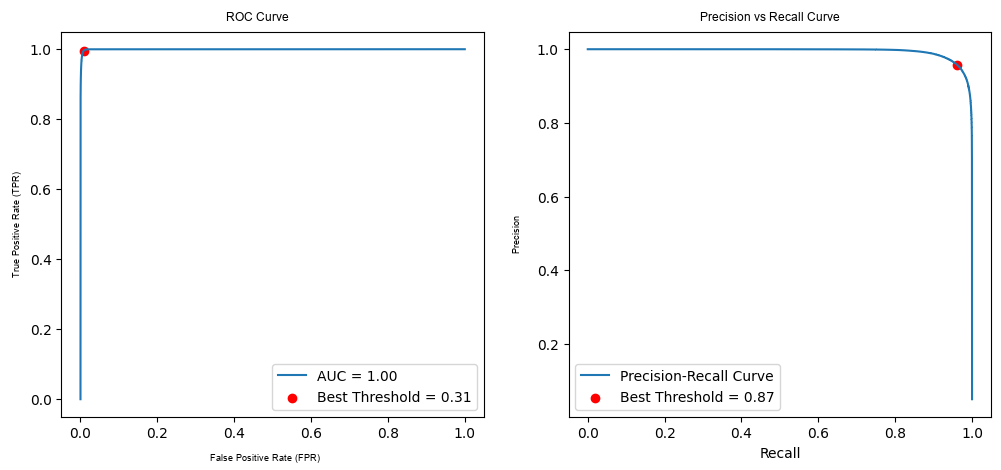

Best ROC threshold: 0.31
Best precision-recall threshold: 0.87


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.995755,0.962552,0.965666,0.997643,0.964107,0.999725,0.930701,0.961851,0.961852,0.869487
Test,0.995900,0.956662,0.962043,0.997692,0.959345,0.999689,0.921867,0.957186,0.957190,0.869487


In [15]:
# Run the evaluation helper
testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)
best_threshold_roc, best_threshold_pr = analyze_threshold(model_base, testloader)

print(f"Best ROC threshold: {best_threshold_roc:.2f}")
print(f"Best precision-recall threshold: {best_threshold_pr:.2f}")
threshold_base=best_threshold_pr

train_metrics = evaluate_model_with_metrics(model_base, trainset, threshold=threshold_base)
test_metrics = evaluate_model_with_metrics(model_base, testset, threshold=threshold_base)

# Exibe os resultados em um DataFrame
results_df_base = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
results_df_base

<!-- mtlearn-icpr2026-doc -->
## CFP Evaluation

The CFP-enhanced model is evaluated with the same test loader and metric procedure. Comparing these outputs with the baseline cells above shows the effect of adding connected-filter preprocessing to the backbone.


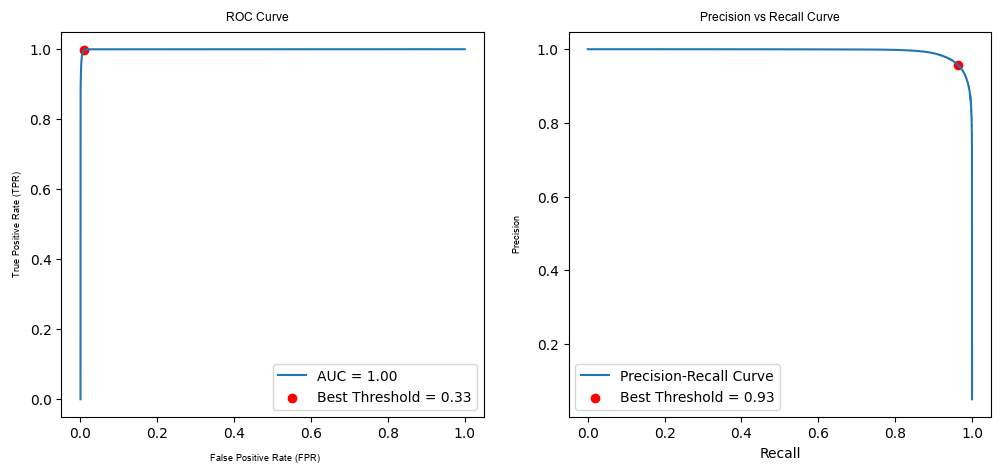

Best ROC threshold: 0.33
Best precision-recall threshold: 0.93


,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,AUC-ROC,Jaccard Index,Cohen's Kappa,MCC,Threshold
Train,0.995853,0.965921,0.963752,0.997867,0.964835,0.999737,0.93206,0.962632,0.962633,0.934184
Test,0.995990,0.957549,0.962946,0.997739,0.960240,0.999709,0.92352,0.958128,0.958132,0.934184


In [16]:
# Run the evaluation helper
testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)
best_threshold_roc, best_threshold_pr = analyze_threshold(model, testloader)

print(f"Best ROC threshold: {best_threshold_roc:.2f}")
print(f"Best precision-recall threshold: {best_threshold_pr:.2f}")
threshold=best_threshold_pr

train_metrics = evaluate_model_with_metrics(model, trainset, threshold=threshold)
test_metrics = evaluate_model_with_metrics(model, testset, threshold=threshold)

# Exibe os resultados em um DataFrame
results_df = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
results_df